#  Cargar todos los archivos CSV que se encuentran en la carpeta GuardarDatos. Luego los uniremos en una sola tabla.

Este notebook realiza las siguientes tareas:

Carga los archivos CSV de la carpeta Db.

Une todos los archivos en un solo DataFrame.

Verifica y muestra los duplicados basados en el tweet_id.

Elimina los duplicados.

Reemplaza el tweet_id por un índice numérico único.

Guarda los datos procesados en un nuevo archivo CSV.

# Codigo Depurado

✅ Archivo cargado: comentarios_imss.csv
✅ Archivo cargado: comentarios_imss_20250722_190710.csv
✅ Archivo cargado: comentarios_imss_20250722_191004.csv
✅ Archivo cargado: comentarios_imss_4.csv
✅ Archivo cargado: comentarios_imss_urls_1.csv
✅ Archivo cargado: comentarios_imss_urls_12.csv
✅ Archivo cargado: comentarios_imss_urls_13.csv
✅ Archivo cargado: comentarios_imss_urls_1333333.csv
✅ Archivo cargado: comentarios_imss_urls_14.csv
✅ Archivo cargado: comentarios_imss_urls_15.csv
✅ Archivo cargado: comentarios_imss_urls_16.csv
✅ Archivo cargado: comentarios_imss_urls_2.csv
✅ Archivo cargado: comentarios_imss_urls_3.csv
✅ Archivo cargado: comentarios_imss_urls_4.csv
✅ Archivo cargado: comentarios_imss_urls_5.csv
✅ Archivo cargado: comentarios_imss_urls_6.csv
✅ Archivo cargado: comentarios_imss_urls_7.csv
✅ Archivo cargado: comentarios_imss_urls_8.csv
✅ Archivo cargado: comentarios_imss_urls_9.csv
✅ Archivo cargado: comentarios_limpios.csv
✅ Archivo cargado: tweets_clasificados.csv
✅ Ar

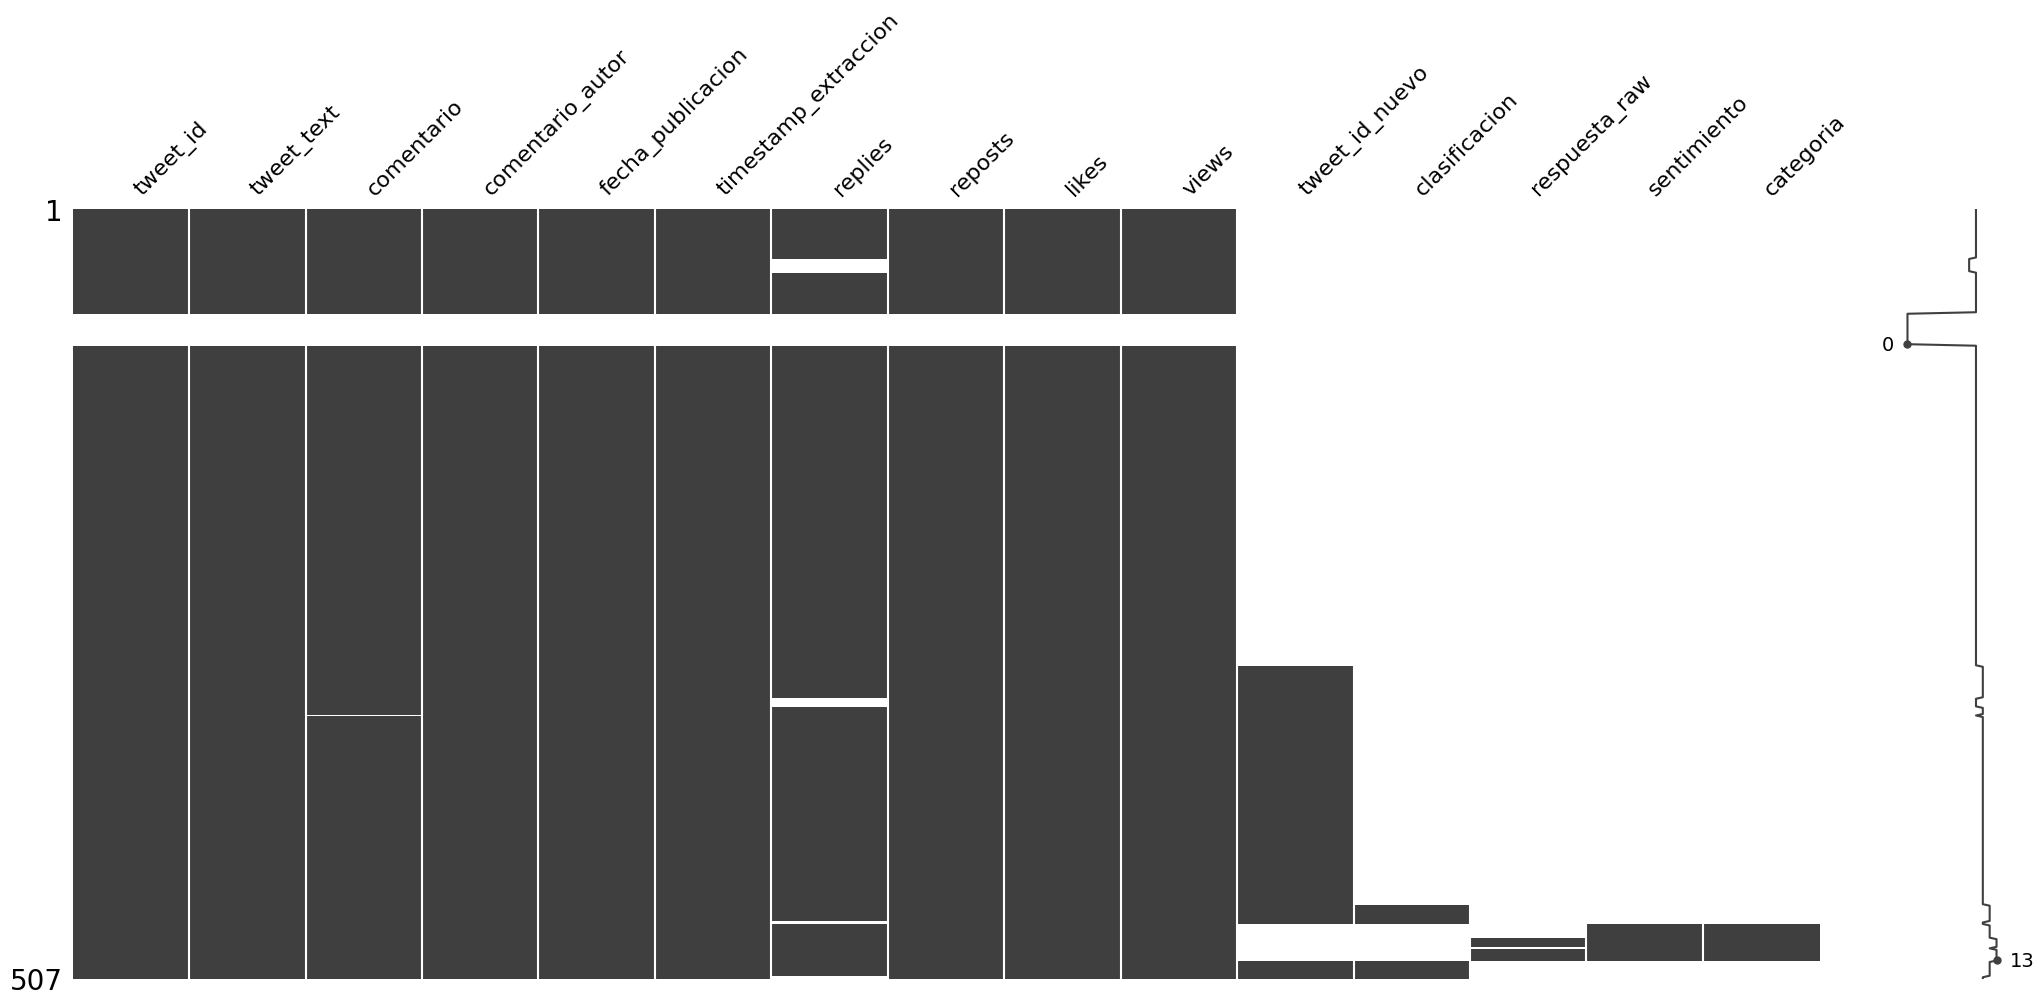

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              486 non-null    object 
 1   tweet_text            486 non-null    object 
 2   comentario            485 non-null    object 
 3   comentario_autor      486 non-null    object 
 4   fecha_publicacion     486 non-null    object 
 5   timestamp_extraccion  486 non-null    object 
 6   replies               467 non-null    float64
 7   reposts               486 non-null    float64
 8   likes                 486 non-null    float64
 9   views                 486 non-null    float64
 10  tweet_id_nuevo        182 non-null    float64
 11  clasificacion         25 non-null     object 
 12  respuesta_raw         14 non-null     object 
 13  sentimiento           24 non-null     object 
 14  categoria             24 non-null     object 
dtypes: float64(5), object(1

In [1]:
# --- Importar librerías necesarias ---
import os
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import unicodedata

# --- Ruta de la carpeta donde están los CSV ---
folder_path = '../db/'

# --- Función para cargar y concatenar CSVs con manejo de errores y delimitadores ---
def cargar_datos_csv(carpeta):
    if not os.path.exists(carpeta):
        raise FileNotFoundError(f"❌ La carpeta '{carpeta}' no existe.")
        
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    if not archivos_csv:
        raise FileNotFoundError(f"❌ No se encontraron archivos CSV en la carpeta '{carpeta}'.")

    lista_df = []
    for archivo in archivos_csv:
        ruta = os.path.join(carpeta, archivo)
        try:
            df = pd.read_csv(ruta, sep=None, engine='python', on_bad_lines='skip')
            lista_df.append(df)
            print(f"✅ Archivo cargado: {archivo}")
        except Exception as e:
            print(f"❌ Error al leer '{archivo}': {e}")

    if not lista_df:
        raise ValueError("❌ No se pudo cargar ningún archivo CSV correctamente.")
    
    return pd.concat(lista_df, ignore_index=True)

# --- Función para limpiar texto ---
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # Eliminar URLs
    texto = re.sub(r'[^a-zA-Záéíóúüñ0-9\s]', '', texto)  # Quitar símbolos
    texto = re.sub(r'\s+', ' ', texto).strip()           # Quitar espacios extras
    texto = unicodedata.normalize('NFKD', texto)         # Normalizar acentos
    return texto

# --- Cargar los datos ---
df = cargar_datos_csv(folder_path)

# --- Visualización de valores nulos ---
print("\n📊 Visualización de valores nulos:")
msno.matrix(df)
plt.show()
df.info()

# --- Validar existencia de la columna 'comentario' ---
if 'comentario' not in df.columns:
    raise ValueError("❌ La columna 'comentario' no está presente en los archivos cargados.")

# --- LIMPIEZA DEL CAMPO 'comentario' ---
df = df.copy()

# 1. Eliminar comentarios nulos o vacíos
df = df.dropna(subset=['comentario'])
df = df[df['comentario'].str.strip() != '']

# 2. Eliminar comentarios duplicados
df = df.drop_duplicates(subset='comentario', keep='first')

# 3. Limpiar texto del comentario
df['comentario'] = df['comentario'].apply(limpiar_texto)

# 4. Generar ID único
df['tweet_id_nuevo'] = range(1, len(df) + 1)

# 5. Guardar archivo limpio
output_file = os.path.join(folder_path, 'comentarios_limpios.csv')
df.to_csv(output_file, index=False)

# 6. Validar limpieza
print("\n✅ Resumen final:")
print(f"- Comentarios nulos: {df['comentario'].isnull().sum()}")
print(f"- Comentarios vacíos: {(df['comentario'].str.strip() == '').sum()}")
print(f"- Total de comentarios únicos: {df.shape[0]}")
print(f"📁 Datos limpios guardados en: {output_file}")

# --- CORRECCIÓN DE COMILLAS EN EL CSV ---
with open(output_file, 'r', encoding='utf-8') as f:
    contenido = f.read()

# Reemplazar triple comillas dobles por comillas simples
contenido_corregido = contenido.replace('"""', "'")

# Guardar el archivo corregido
output_file_corr = os.path.join(folder_path, '../db/db_procesadas/comentarios_limpios_reemplazado2.csv')
with open(output_file_corr, 'w', encoding='utf-8') as f:
    f.write(contenido_corregido)

print(f"📁 Archivo corregido guardado como: {output_file_corr}")
